## Loading

In [6]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.Helper_fun import float_range
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import cmcrameri.cm


In [7]:
# import sys
# !{sys.executable} -m pip install pycairo

Setup matplotlib


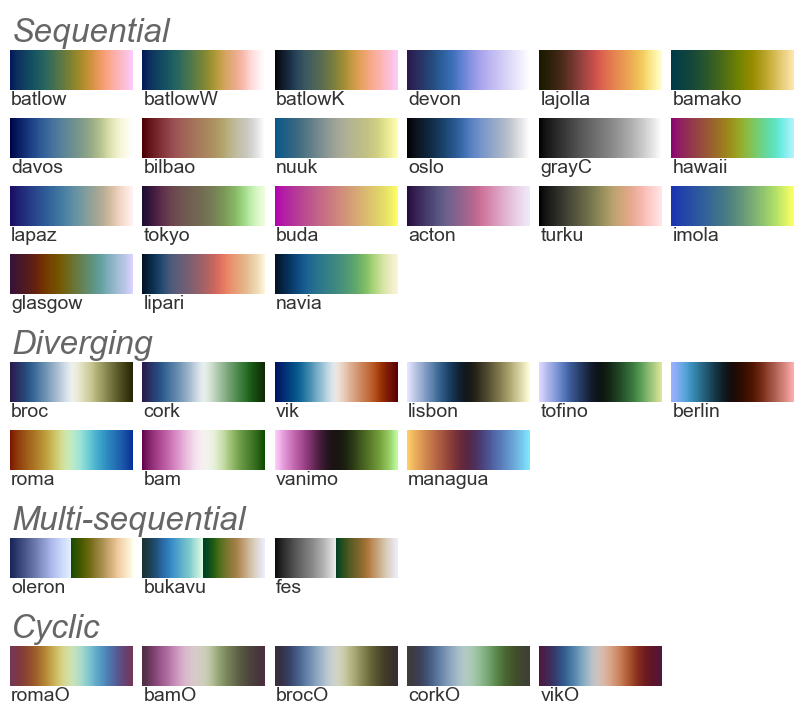

In [8]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

Set parameters

In [9]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2016)]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# classifiacation_palette = ['#00429d', '#93003a','#ffffe0']
classifiacation_palette = cmcrameri.cm.actonS.colors[[i for i in range(10) if i != 1],:]
temperature_palette = ["#0d0d0f",'#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
default_colormap=cmcrameri.cm.acton


Load data

In [10]:
temp_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","temp_occurance_rate.csv"))
pole_temp_or =pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","pole_temp_occurance_rate.csv"))
pole_temp_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","pole_temp_occurance_rate_glac_possible.csv"))
pole_temp_season_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","pole_temp_season_occurance_rate.csv"))
pole_temp_season_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","pole_temp_season_occurance_rate_glac_possible.csv"))
glac_thresh_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","glac_thresh_occurance_rates.csv"))
hq_pole_temp_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Publication_figures/Multiyear_analysis","hq_pole_temp_occurance_rate_glac_possible_2.csv"))
# temp_or["Occurance rate"] *= 100
pole_temp_or["Occurance rate"] *= 100
pole_temp_or_glac_possible['Occurance rate']*= 100
pole_temp_season_or["Occurance rate"] *= 100
pole_temp_season_or_glac_possible['Occurance rate']*= 100
hq_pole_temp_or_glac_possible["Occurance rate"] *= 100

In [11]:
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader
data_2010 = ChunkLoader([2010],config=config)
glac_df = data_2010.glac_chunk
glac_df.loc[:,"Peak IF"]=glac_df.apply(lambda x: x["ice_frac_hist"][x["Glac_peak_ind"]], axis =1)

Cloud_fps: {2010: '/wolke_scratch/dnikolo/Final_results/2010_all.parquet'}


## Glaciation event analysis

In [41]:
glac_df.loc[:,"Final IF"]=glac_df.apply(lambda x: x["ice_frac_hist"][-1], axis =1)

In [12]:
glac_df.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'tracknumber', 'is_large_pix_cloud',
       'is_cot_valid_cloud', 'is_ctp_valid_cloud', 'is_liq', 'is_mix',
       'is_ice', 'max_water_frac', 'max_ice_fraction', 'avg_size[km]',
       'max_size[km]', 'min_size[km]', 'avg_size[px]', 'max_size[px]',
       'min_size[px]', 'track_start_time', 'track_length', 'avg_cot',
       'avg_ctp', 'avg_ctt', 'glaciation_start_time', 'glaciation_end_time',
       'avg_lat', 'avg_lon', 'start_ice_fraction', 'end_ice_fraction',
       'ice_frac_hist', 'cot_hist', 'cot_std_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_std_hist', 'ctp_nan_frac_hist', 'ctt_hist',
       'ctt_std_hist', 'lat_hist', 'lon_hist', 'size_hist_km', 'min_temp',
       'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]', 'Radius [km]',
       'Level', 'Optical Thickness', 'Cloud type', 'Season', 'Peak IF',
   

In [13]:
glac_df.iloc[0].cot_hist

array([11.483263  , 10.536472  ,  7.244499  ,  7.124585  ,  4.6011295 ,
        3.5008743 ,  2.7067327 ,  1.4746604 ,  1.1313317 ,  0.78493416,
        0.6486547 ,  0.54458845,  0.661404  ,  1.0711681 ,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan], dtype=float32)

In [46]:
(glac_df["Peak IF"]<0.9).value_counts(normalize=True)

Peak IF
True     0.832484
False    0.167516
Name: proportion, dtype: float64

In [14]:
def calc_delta_cot(x):
    if np.isnan(x.cot_hist).any():
        return -1000
    else:
        return x["cot_hist"][:x["Glac_peak_ind"]].mean()-x["cot_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)) else -1000

In [15]:
glac_df.loc[:,"delta_cot"] = glac_df.apply(calc_delta_cot , axis =1)

In [16]:
glac_df[glac_df.delta_cot!=-1000].cot_hist

3         [5.36752, 7.4641333, 4.2764244, 4.050244, 2.47...
11        [7.1773014, 7.32541, 8.314839, 5.5981717, 3.96...
13        [3.0962574, 2.2611165, 1.6314051, 1.7325488, 0...
32                [2.950702, 2.1567886, 8.851489, 1.621783]
56        [5.310205, 4.7464714, 5.895687, 4.4695015, 3.0...
                                ...                        
135299    [8.987297, 8.718383, 7.053953, 6.2052803, 6.65...
135300    [11.239457, 9.869899, 10.631649, 9.828269, 11....
135304    [11.262066, 12.733596, 17.893295, 18.16604, 15...
135308    [14.733031, 13.972833, 15.191075, 17.615807, 1...
135323    [90.21949, 77.92952, 83.59905, 96.250725, 132....
Name: cot_hist, Length: 17131, dtype: object

In [17]:
(glac_df.delta_cot==-1000).value_counts()

delta_cot
True     78263
False    17131
Name: count, dtype: int64

In [26]:
def calc_delta_cot_frac(x):
    if np.isnan(x.cot_hist).any():
        return -1000
    elif (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)):
        if (x["cot_hist"][x["Glac_peak_ind"]+1:].mean()!=0) and (x["cot_hist"][:x["Glac_peak_ind"]].mean()!=0):
            return x["cot_hist"][x["Glac_peak_ind"]+1:].mean()/x["cot_hist"][:x["Glac_peak_ind"]].mean()-1  
        else:
            return -1000
    else:
        return -1000
glac_df.loc[:,"delta_cot_frac"] = glac_df.apply(calc_delta_cot_frac , axis =1)

In [37]:
print(glac_df[glac_df["delta_cot"]!=-1000]["delta_cot"].median())
print(glac_df[(glac_df["delta_cot_frac"]!=-1000) & (glac_df["delta_cot_frac"]<9) ]["delta_cot_frac"].describe())

1.4342899322509766
count    17044.000000
mean         0.066036
std          0.979133
min         -0.998819
25%         -0.485456
50%         -0.184130
75%          0.268030
max          8.958490
Name: delta_cot_frac, dtype: float64


2         False
3         False
4         False
5         False
8         False
          ...  
135318    False
135320    False
135321    False
135323     True
135324    False
Name: delta_cot_frac, Length: 95394, dtype: bool

In [ ]:
(glac_df[glac_df["delta_cot_frac"] != -1000]["delta_cot_frac"]>9).value_counts()

delta_cot_frac
False    17044
True        81
Name: count, dtype: int64

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='delta_cot_frac', ylabel='Count'>

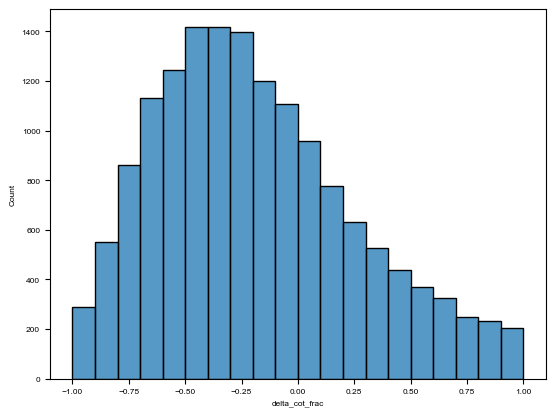

In [32]:
# Define bins from -1 to 1 with 0.1 step
bins = np.arange(-1, 1.1, 0.1)

# Filter and plot
sns.histplot(glac_df[glac_df["delta_cot_frac"] != -1000]["delta_cot_frac"], bins=bins)

In [20]:
search_rad=1
search_rad-=1
calc_mean_diff_pre_post_glac_rad  = lambda x: np.array([x["ice_frac_hist"][x["Glac_peak_ind"]-i]-x["ice_frac_hist"][x["Glac_peak_ind"]+i] for i in range(1,2+search_rad)]).mean() if (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)-search_rad) else -100
cloud = glac_df.iloc[1]
calc_mean_diff_pre_post_glac  = lambda x: x["ice_frac_hist"][:x["Glac_peak_ind"]].mean()-x["ice_frac_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)) else -100
calc_post_glac_drop_rad_1  = lambda x: np.array([x["ice_frac_hist"][x["Glac_peak_ind"]]-x["ice_frac_hist"][x["Glac_peak_ind"]+i] for i in range(1,2+search_rad)]).mean() if (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)-search_rad) else -100
calc_post_glac_drop  = lambda x: x["ice_frac_hist"][x["Glac_peak_ind"]]-x["ice_frac_hist"][x["Glac_peak_ind"]+1:].mean() if (x["Glac_peak_ind"]<x["track_length"]/pd.Timedelta(minutes=15)) else -100

print(cloud["ice_frac_hist"])
print(cloud["ice_frac_hist"][cloud["Glac_peak_ind"]])
print(calc_post_glac_drop(cloud))
print(calc_post_glac_drop_rad_1(cloud))

[0.05555558 0.08332169 0.17637454 0.23411894 0.31530914 0.46292337
 0.45833373]
0.4629233678181966
0.00458963712056476
0.00458963712056476


In [21]:
glac_df.loc[:,"Pre_post_glac_dif_rad_1"]=glac_df.apply(calc_mean_diff_pre_post_glac_rad , axis =1)
glac_df.loc[:,"Pre_post_glac_dif"]=glac_df.apply(calc_mean_diff_pre_post_glac , axis =1)
glac_df.loc[:,"Post_glac_drop"]=glac_df.apply(calc_post_glac_drop , axis =1)
glac_df.loc[:,"Post_glac_drop_rad_1"]=glac_df.apply(calc_post_glac_drop_rad_1 , axis =1)

In [22]:
print(glac_df[glac_df["Pre_post_glac_dif_rad_1"]!=-100]["Pre_post_glac_dif_rad_1"].median())
print(glac_df[glac_df["Pre_post_glac_dif"]!=-100]["Pre_post_glac_dif"].median())
print(glac_df[glac_df["Post_glac_drop"]!=-100]["Post_glac_drop"].median())
print(glac_df[glac_df["Post_glac_drop_rad_1"]!=-100]["Post_glac_drop_rad_1"].median())

-0.029628482165637293
-0.13150313674851344
0.22516501561614788
0.12991864769547073


In [23]:
(glac_df["Pre_post_glac_dif"]==0).value_counts(normalize=True)

Pre_post_glac_dif
False    0.999811
True     0.000189
Name: proportion, dtype: float64

In [24]:
(glac_df["Final IF"]==glac_df.loc[:,"Peak IF"]).value_counts(normalize=True)

False    0.582112
True     0.417888
Name: proportion, dtype: float64

In [25]:
(glac_df["Glac_peak_ind"]==glac_df["track_length"]/pd.Timedelta(minutes=15)).value_counts(normalize=True)

False    0.591358
True     0.408642
Name: proportion, dtype: float64

## Publication figures

In [7]:
# mpl.use('cairo')

In [8]:
small_ax_range=(0,15)
large_ax_range=(-2.5,12.5)
var_thresh_ax_range=(0,35)
small_major_ticks=np.linspace(small_ax_range[0],small_ax_range[1],4)
small_minor_ticks=np.arange(small_ax_range[0],small_ax_range[1],0.5)
large_major_ticks=list(np.linspace(large_ax_range[0],large_ax_range[1],7))
# large_major_ticks.append(0.0)
large_minor_ticks=np.arange(large_ax_range[0],large_ax_range[1],0.5)
var_thresh_major_ticks=np.linspace(var_thresh_ax_range[0],var_thresh_ax_range[1],8)
var_thresh_minor_ticks=np.arange(var_thresh_ax_range[0],var_thresh_ax_range[1],1)
large_major_ticks
large_minor_ticks

array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,
        3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,  7.5,  8. ,
        8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. ])

Combined

In [ ]:
overall = pole_temp_or_glac_possible.groupby([ 'min_temp', 'Hemisphere'])['Occurance rate'].agg(['mean', 'std']).reset_index()
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
diff_mean/diff_std

min_temp
-36   -0.536823
-30    3.429912
-24    3.705759
-18    2.257346
-12    0.950255
-6          NaN
dtype: float64

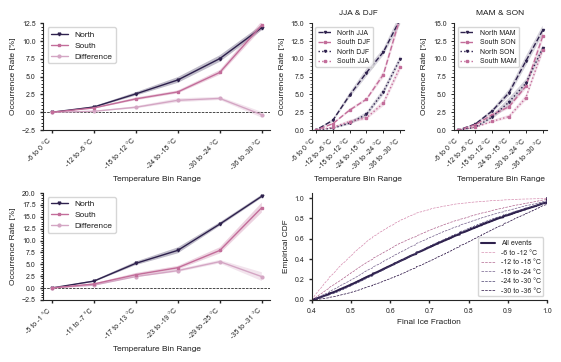

In [41]:

#############
## LEFT SIDE
############# 
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')
df_pivot = pole_temp_or_glac_possible.pivot_table(
    index=['year', 'min_temp'],
    columns='Hemisphere',
    values='Occurance rate'
).reset_index()

# 2. Compute the difference: North minus South
df_pivot['diff_NS'] = df_pivot['North'] - df_pivot['South']
diff_mean = df_pivot.groupby('min_temp')['diff_NS'].mean()
diff_std = df_pivot.groupby('min_temp')['diff_NS'].std()

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or_glac_possible.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
bin_labels_lim = [f"{int(t+1)} to {int(t+5)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(5.501, 3.504), constrained_layout=True)
gs = gridspec.GridSpec(2, 4,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference

ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)

ax1.set_xticks(x)
ax1.set_yticks(large_major_ticks)
ax1.set_yticks(large_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)
temp_handles, temp_labels = ax1.get_legend_handles_labels()
order = [0,2,1]
ax1.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left ----
ax4 = fig.add_subplot(gs[1, :2])


# 1. Compute overall occurrence rates (mean and std across years)
overall = hq_pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')
df_pivot = hq_pole_temp_or_glac_possible.pivot_table(
    index=['year', 'min_temp'],
    columns='Hemisphere',
    values='Occurance rate'
).reset_index()

# 2. Compute the difference: North minus South
df_pivot['diff_NS'] = df_pivot['North'] - df_pivot['South']
diff_mean = df_pivot.groupby('min_temp')['diff_NS'].mean()
diff_std = df_pivot.groupby('min_temp')['diff_NS'].std()
# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02


ax4.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax4.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
ax4.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax4.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax4.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax4.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax4.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)


# ax4
ax4.set_xticks(x)
ax4.set_yticks(np.linspace(-2.5,20,10))
ax4.set_yticks(np.arange(-2.5,20,0.5),minor=True)

ax4.set_xticklabels(bin_labels_lim, rotation=45, ha='right',fontsize=5)
ax4.invert_xaxis()
ax4.set_xlabel("Temperature Bin Range",fontsize=6)
ax4.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax4.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax4.legend(fontsize=5)
ax4.set_xlim(5.2, -0.2)
ax4.set_ylim((-2.5,20))
temp_handles, temp_labels = ax4.get_legend_handles_labels()
order = [0,2,1]
ax4.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax4.xaxis.set_ticks_position('bottom')
ax4.yaxis.set_ticks_position('left')
ax4.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax4.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax4.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax1.spines[['right', 'top']].set_visible(False)
ax4.spines[['right', 'top']].set_visible(False)


###########################
## RIGHT SIDE
###########################

sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = hq_pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or_glac_possible.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
# fig = plt.figure(figsize=(3.504, 3.504), constrained_layout=True)
# gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax5 = fig.add_subplot(gs[1, 2:])

# sns.swarmplot(
#     ax = ax5, x="bin_label", y="Peak IF", data=dots_df,
#     order=order, palette=palette, size=1
# )

# # glac_thresh_list=glac_thresh_or["threshold"].unique()
# var_glac_thresh_cm = default_colormap(np.linspace(0, 0.7, len(glac_thresh_list)))[::-1]
# for glac_i, glac_threshold in enumerate(glac_thresh_list):
#     temp_y=glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].mean()[glac_threshold]
#     # ax5.plot(x,temp_y , marker='s', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
#     #       linewidth=1,markersize=2)
#     ax5.plot(x,temp_y , marker='o', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
#           linewidth=1,markersize=2)
#     temp_std= glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].std()[glac_threshold]
#     ax5.fill_between(
#         x,
#         temp_y - temp_std,
#         temp_y + temp_std, alpha=0.3,edgecolor="none",color=var_glac_thresh_cm[glac_i]
#     )
# 1. grab your data
def get_cdf_x_y(data):
    """
    Sorts the data and computes the cumulative probabilities.
    """
    sorted_data = np.sort(data)
    cdf_y = np.arange(1, sorted_data.size + 1) / sorted_data.size
    return sorted_data, cdf_y

# 2. sort and compute cumulative probabilities
cdf_x, cdf_y =get_cdf_x_y(glac_df["Peak IF"].dropna().values)


# 3. plot
ax5.step(cdf_x, cdf_y, where="post",color=classifiacation_palette[0],label="All events")
min_temp_list = glac_df["min_temp"].unique()
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]

for i,min_temp in enumerate(min_temp_list):
    temp_df = glac_df[glac_df["min_temp"] == min_temp]
    cdf_x, cdf_y = get_cdf_x_y(temp_df["Peak IF"].dropna().values)
    ax5.step(cdf_x, cdf_y, where="post",color=var_temp_cm[i],label=f"{int(min_temp+6)} to {int(min_temp)} °C",linestyle="--",linewidth=0.5)
# ax5.step
ax5.set_ylim(0, 1.05)
ax5.set_xlim(0.4, 1.0)
# ax5.set_xticks(x)
# ax5.set_yticks(var_thresh_major_ticks)
# ax5.set_yticks(var_thresh_minor_ticks,minor=True)

# ax5.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
# ax5.invert_xaxis()
ax5.set_xlabel("Final Ice Fraction",fontsize=6)
ax5.set_ylabel("Empirical CDF",fontsize=6)
# ax5.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax5.legend(fontsize=5,loc='lower right')
# ax5.set_xlim(5.2, -0.2)
# ax5.set_ylim(var_thresh_ax_range)
# ax5.legend()

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax5.xaxis.set_ticks_position('bottom')
ax5.yaxis.set_ticks_position('left')
ax5.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax5.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax5.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Top middle left: JJA & DJF ---
ax2 = fig.add_subplot(gs[0, 2])
style_list=['--', ':']
for idx in range(2):
    season_n = seas_pairs[0][idx]
    season_s = seas_pairs[0][(idx+1)%2]
    style = style_list[idx]
    mn_n, sd_n = get_season_data(season_n, 'North')
    mn_s, sd_s = get_season_data(season_s, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season_n}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season_s}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2,edgecolor='none'
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2,edgecolor='none'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("JJA & DJF",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Top most right right: MAM & SON ---
ax3 = fig.add_subplot(gs[0, 3])
style_list=['--', ':']

for idx in range(2):
    season_n = seas_pairs[1][idx]
    season_s = seas_pairs[1][(idx+1)%2]
    style = style_list[idx]
    mn_n, sd_n = get_season_data(season_n, 'North')
    mn_s, sd_s = get_season_data(season_s, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season_n}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season_s}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2,edgecolor='none'
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2,edgecolor='none'
    )
# ax5.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("MAM & SON",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax5.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
ax3.spines[['right', 'top']].set_visible(False)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_combined.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

## Draft publication figures

Left side

NameError: name 'large_major_ticks' is not defined

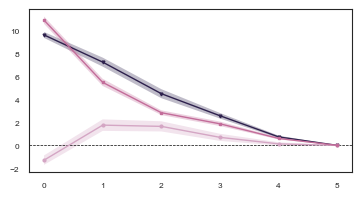

In [7]:

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or_glac_possible.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.504), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)

ax1.set_xticks(x)
ax1.set_yticks(large_major_ticks)
ax1.set_yticks(large_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)
temp_handles, temp_labels = ax1.get_legend_handles_labels()
order = [0,2,1]
ax1.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, :])


# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02


ax2.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax2.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax2.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax2.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax2.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax2.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax2.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)


ax2
ax2.set_xticks(x)
ax2.set_yticks(large_major_ticks)
ax2.set_yticks(large_minor_ticks,minor=True)

ax2.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax2.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax2.legend(fontsize=5)
ax2.set_xlim(5.2, -0.2)
ax2.set_ylim(large_ax_range)
temp_handles, temp_labels = ax2.get_legend_handles_labels()
order = [0,2,1]
ax2.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax1.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_left.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

Right side

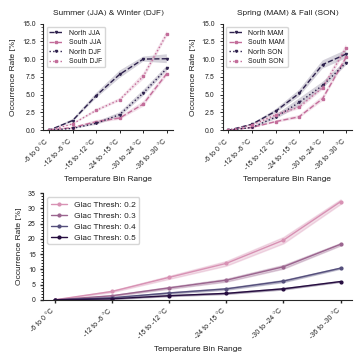

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.504), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[1, :])

glac_thresh_list=glac_thresh_or["threshold"].unique()
var_glac_thresh_cm = default_colormap(np.linspace(0, 0.7, len(glac_thresh_list)))[::-1]
for glac_i, glac_threshold in enumerate(glac_thresh_list):
    temp_y=glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].mean()[glac_threshold]
    # ax1.plot(x,temp_y , marker='s', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
    #       linewidth=1,markersize=2)
    ax1.plot(x,temp_y , marker='o', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
          linewidth=1,markersize=2)
    temp_std= glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].std()[glac_threshold]
    ax1.fill_between(
        x,
        temp_y - temp_std,
        temp_y + temp_std, alpha=0.3,edgecolor="none",color=var_glac_thresh_cm[glac_i]
    )
# # Fill‐between for error bands
# ax1.fill_between(
#     x,
#     north_over['mean'] - north_over['std'],
#     north_over['mean'] + north_over['std'],
#     color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
# )
# ax1.fill_between(
#     x,
#     south_over['mean'] - south_over['std'],
#     south_over['mean'] + south_over['std'],
#     color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
# )
# ax1.fill_between(
#     x,
#     diff_mean - diff_std,
#     diff_mean + diff_std,
#     color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
# )

ax1.set_xticks(x)
ax1.set_yticks(var_thresh_major_ticks)
ax1.set_yticks(var_thresh_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(var_thresh_ax_range)
ax1.legend()

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[0, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2,edgecolor='none'
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2,edgecolor='none'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Summer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[0, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2,edgecolor='none'
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2,edgecolor='none'
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Spring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax1.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
ax3.spines[['right', 'top']].set_visible(False)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_right.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

## Draft Completeness figure

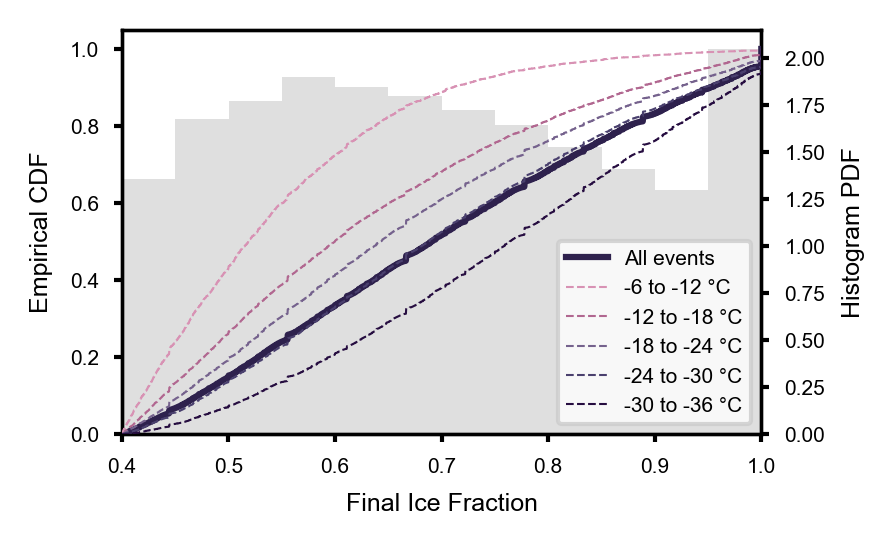

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.501/2, 3.504/2), dpi=300)

def get_cdf_x_y(data):
    """
    Sorts the data and computes the cumulative probabilities.
    """
    sorted_data = np.sort(data)
    cdf_y = np.arange(1, sorted_data.size + 1) / sorted_data.size
    return sorted_data, cdf_y

# --- Data and bins ---
data_all = glac_df["Peak IF"].dropna().values
bins = np.arange(0.4001, 1.0 + 0.05, 0.05)  # Bin edges from 0.4 to 1.0 with width 0.05

# --- Create twin y-axis for the histogram (PDF on the right) ---
ax_hist = ax.twinx()

# Put CDF axis visually above histogram axis so the steps aren’t hidden
ax.set_zorder(2)
ax.patch.set_visible(False)

# --- Histogram as PDF in the background (right axis) ---
ax_hist.hist(
    data_all,
    bins=bins,
    density=True,      # PDF
    alpha=0.25,
    color="gray",
    edgecolor="none",
)
ax_hist.set_ylabel("Histogram PDF", fontsize=6)

# --- CDFs on the left axis ---
cdf_x, cdf_y = get_cdf_x_y(data_all)
ax.step(cdf_x, cdf_y, where="post", color=classifiacation_palette[0], label="All events", zorder=3)

min_temp_list = glac_df["min_temp"].unique()
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]

for i, min_temp in enumerate(min_temp_list):
    temp_df = glac_df[glac_df["min_temp"] == min_temp]
    cdf_x, cdf_y = get_cdf_x_y(temp_df["Peak IF"].dropna().values)
    ax.step(
        cdf_x, cdf_y,
        where="post",
        color=var_temp_cm[i],
        label=f"{int(min_temp+6)} to {int(min_temp)} °C",
        linestyle="--",
        linewidth=0.5,
        zorder=3
    )

# --- Axes limits and labels ---
ax.set_ylim(0, 1.05)          # CDF axis (left)
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("Final Ice Fraction", fontsize=6)
ax.set_ylabel("Empirical CDF", fontsize=6)

# --- Tick settings (left CDF axis) ---
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='x', which='both', bottom=True, top=False, length=2, width=1, direction='out', labelsize=5)
ax.tick_params(axis='y', which='minor', bottom=True, top=False, length=1.2, width=0.7, direction='out')
ax.tick_params(axis='y', which='major', left=True, right=False, length=2, width=1, direction='out', labelsize=5)

# --- Tick settings (right histogram axis) ---
ax_hist.tick_params(axis='y', which='major', right=True, left=False, length=2, width=1, direction='out', labelsize=5)
ax_hist.tick_params(axis='y', which='minor', right=True, left=False, length=1.2, width=0.7, direction='out')

# --- Single combined legend ---
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_hist.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=5, loc='lower right')


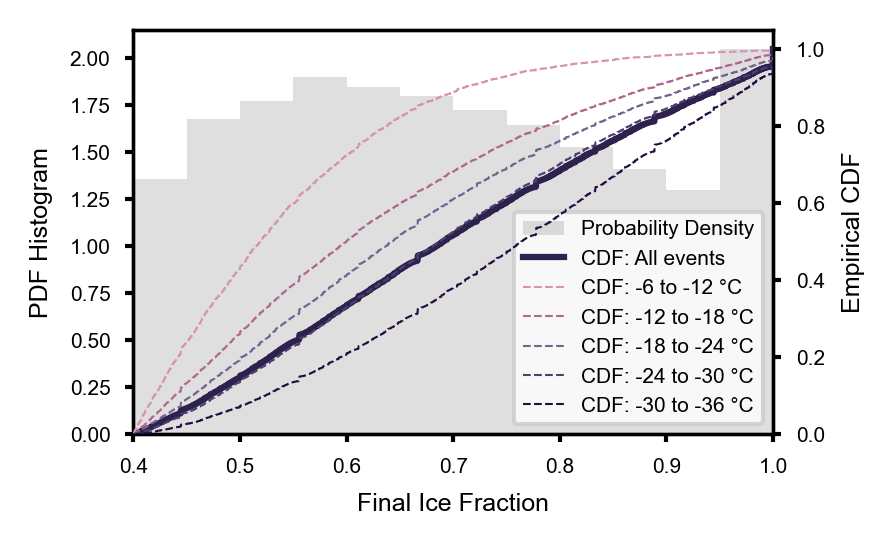

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # for legend box

fig, ax = plt.subplots(figsize=(5.501/2, 3.504/2), dpi=300)  # ax = LEFT axis (hist PDF)

def get_cdf_x_y(data):
    """
    Sorts the data and computes the cumulative probabilities.
    """
    sorted_data = np.sort(data)
    cdf_y = np.arange(1, sorted_data.size + 1) / sorted_data.size
    return sorted_data, cdf_y

# --- Data and bins ---
data_all = glac_df["Peak IF"].dropna().values
bins = np.arange(0.4001, 1.0 + 0.05, 0.05)  # Bin width 0.05

# --- Create twin y-axis for the CDF (right axis) ---
ax_cdf = ax.twinx()

# --- Histogram as PDF on the LEFT axis ---
ax.hist(
    data_all,
    bins=bins,
    density=True,      # PDF
    alpha=0.25,
    color="gray",
    edgecolor="none",
    zorder=1
)
ax.set_ylabel("PDF Histogram", fontsize=6)

# --- CDFs on the RIGHT axis ---
cdf_x, cdf_y = get_cdf_x_y(data_all)
ax_cdf.step(cdf_x, cdf_y, where="post", color=classifiacation_palette[0],
            label="CDF: All events", zorder=3)

min_temp_list = glac_df["min_temp"].unique()
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]

for i, min_temp in enumerate(min_temp_list):
    temp_df = glac_df[glac_df["min_temp"] == min_temp]
    cdf_x, cdf_y = get_cdf_x_y(temp_df["Peak IF"].dropna().values)
    ax_cdf.step(
        cdf_x, cdf_y,
        where="post",
        color=var_temp_cm[i],
        label=f"CDF: {int(min_temp+6)} to {int(min_temp)} °C",
        linestyle="--",
        linewidth=0.5,
        zorder=3
    )

# --- Axes limits and labels ---
ax_cdf.set_ylim(0, 1.05)
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("Final Ice Fraction", fontsize=6)
ax_cdf.set_ylabel("Empirical CDF", fontsize=6)

# --- Tick settings (X and LEFT axis - histogram) ---
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='x', which='both', bottom=True, top=False, length=2, width=1, direction='out', labelsize=5)
ax.tick_params(axis='y', which='minor', bottom=True, top=False, length=1.2, width=0.7, direction='out')
ax.tick_params(axis='y', which='major', left=True, right=False, length=2, width=1, direction='out', labelsize=5)

# --- Tick settings (RIGHT axis - CDF) ---
ax_cdf.tick_params(axis='y', which='major', right=True, left=False, length=2, width=1, direction='out', labelsize=5)
ax_cdf.tick_params(axis='y', which='minor', right=True, left=False, length=1.2, width=0.7, direction='out')

# --- Legend combining both axes ---
hist_patch = Patch(facecolor='gray', alpha=0.25, label='Probability Density')  # legend box for histogram
h1, l1 = ax_cdf.get_legend_handles_labels()
ax.legend([hist_patch] + h1, ['Probability Density'] + l1, fontsize=5, loc='lower right')


In [27]:
glac_df["Peak IF"]

2         0.614801
3         0.462923
4         0.402102
5         0.514800
8         0.645412
            ...   
135318    0.722329
135320    0.757340
135321    0.600062
135323    0.777759
135324    0.622229
Name: Peak IF, Length: 95394, dtype: float64

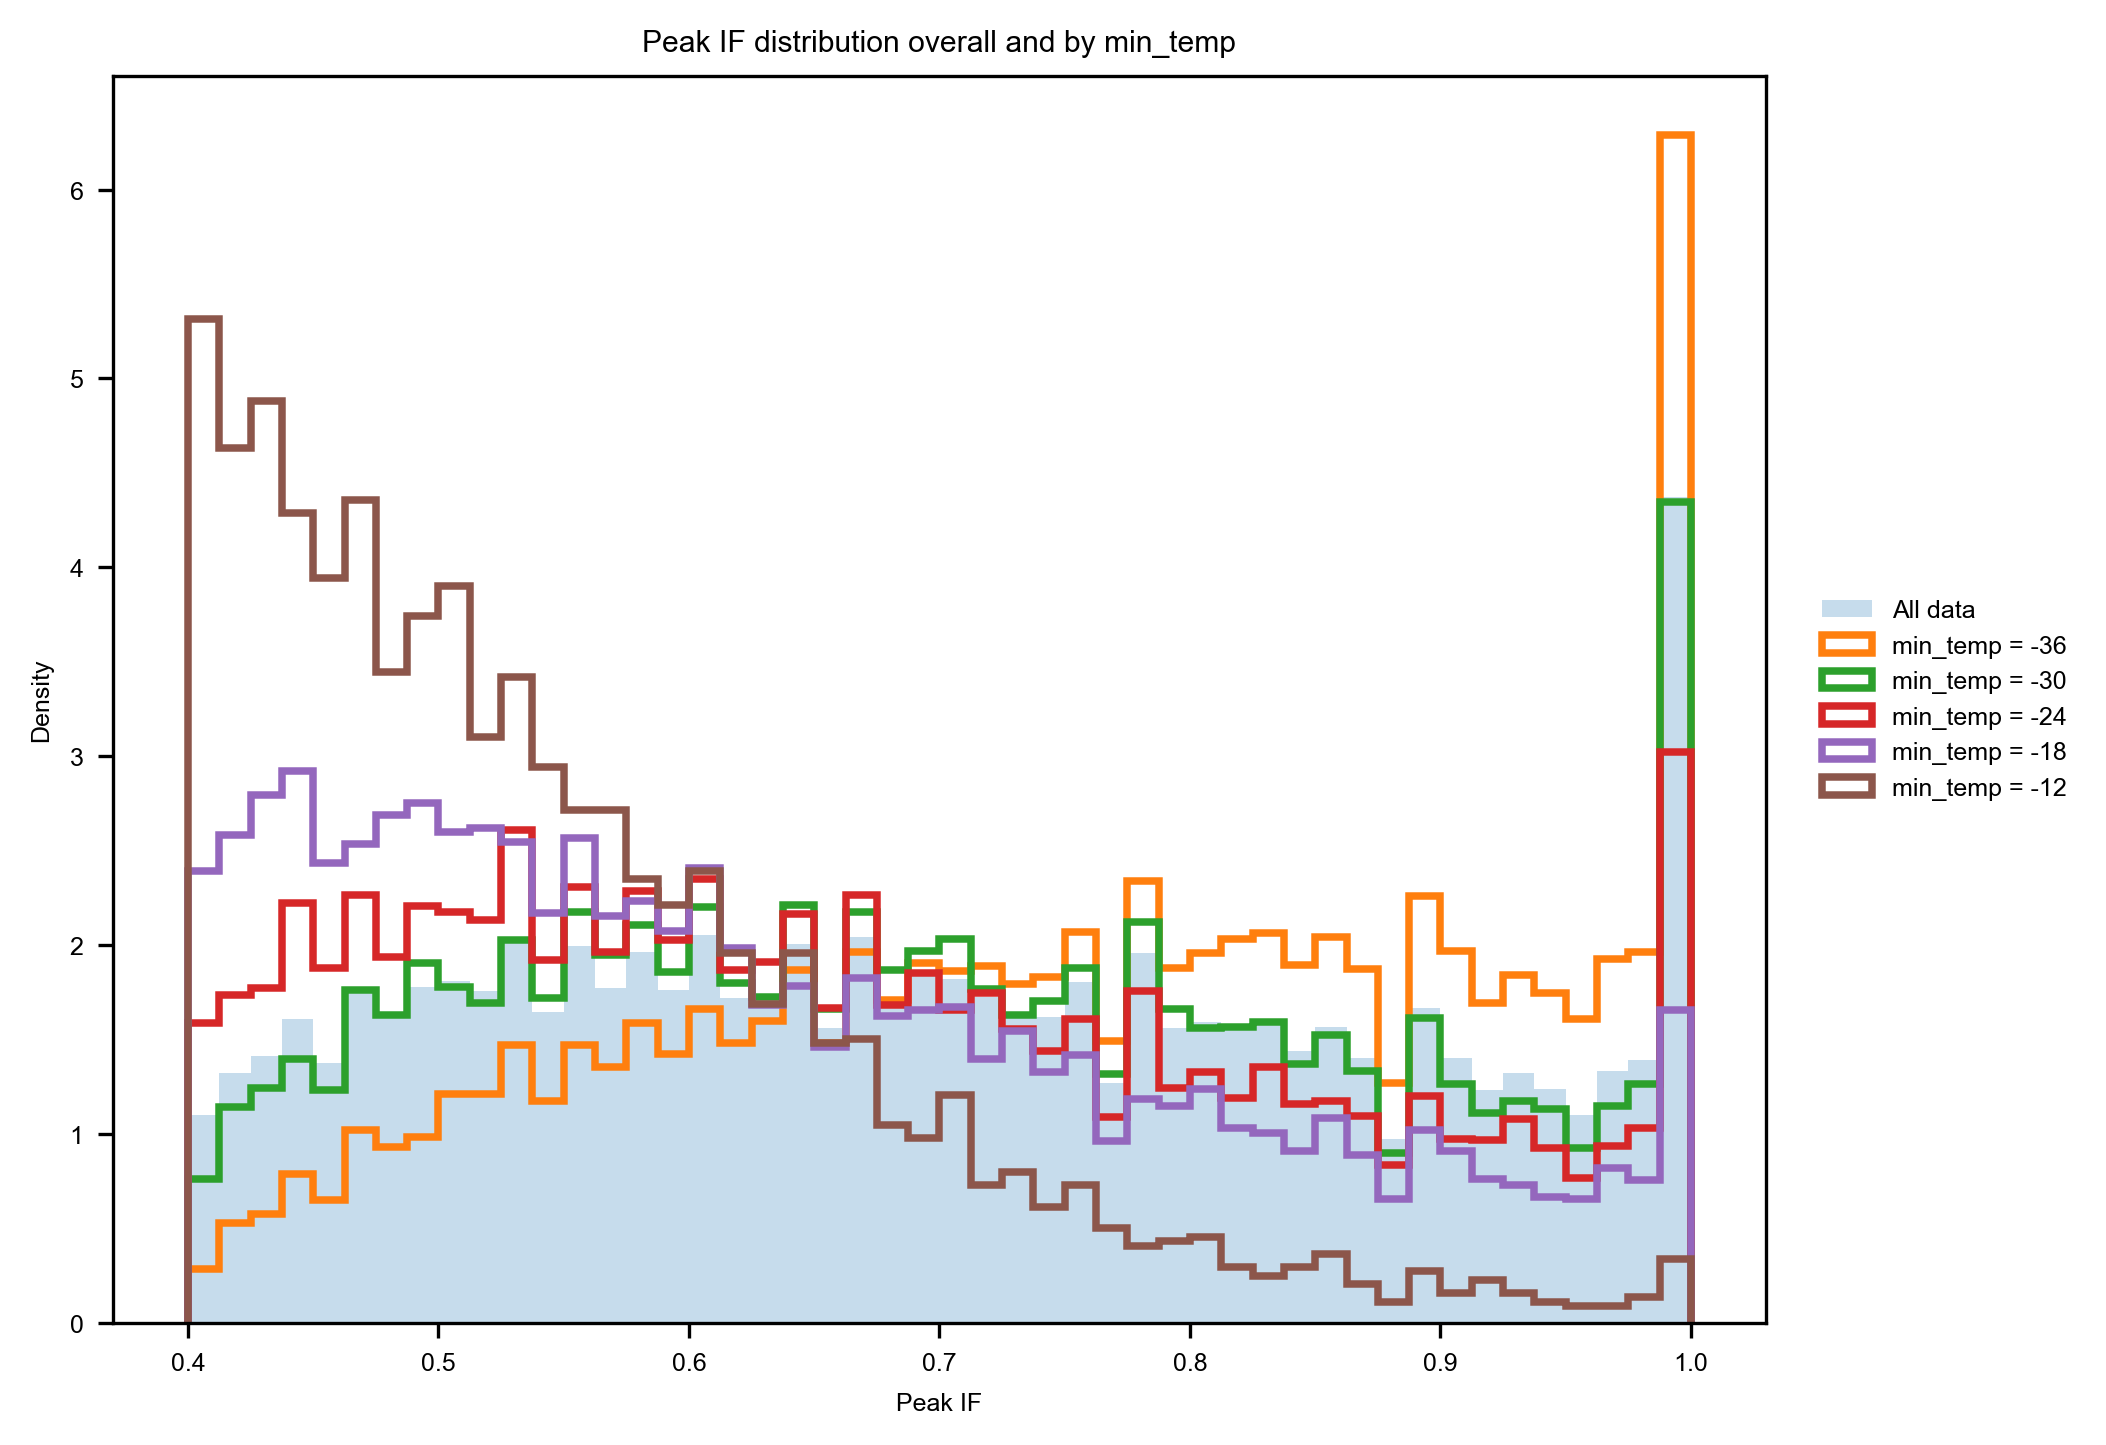

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config you can tweak ---
value_col   = "Peak IF"
group_col   = "min_temp"
use_density = True           # density=True makes shapes comparable across different group sizes
min_group_n = 2              # skip groups with fewer than this many points
top_k_groups = None          # set to an int (e.g., 8) to only plot the largest K groups
title = f"{value_col} distribution overall and by {group_col}"

# --- clean data ---
df = glac_df[[value_col, group_col]].dropna()
# If min_temp is numeric but you want exact-value grouping, leave as-is; if it's near-continuous, consider binning first.

# --- compute common bins via Freedman–Diaconis rule for crisp alignment ---
x_all = df[value_col].to_numpy()
q75, q25 = np.percentile(x_all, [75, 25])
iqr = q75 - q25
n = x_all.size
# Freedman–Diaconis bin width
bw = 2 * iqr * (n ** (-1/3)) if iqr > 0 else 0
if bw > 0:
    # guard against zero-width or degenerate
    x_min, x_max = np.min(x_all), np.max(x_all)
    # ensure at least ~10 bins if data is very tight
    num = max(10, int(np.ceil((x_max - x_min) / bw)))
    bins = np.linspace(x_min, x_max, num + 1)
else:
    # fallback to numpy's automatic rule
    bins = "auto"

# --- optionally limit to top-K most populous groups for readability ---
group_counts = df[group_col].value_counts()
if top_k_groups is not None:
    keep_groups = set(group_counts.head(top_k_groups).index)
    df_plot = df[df[group_col].isin(keep_groups)]
else:
    df_plot = df

# --- plot ---
plt.figure(figsize=(7, 4.8), dpi=300)

# overall (light fill)
plt.hist(
    df_plot[value_col],
    bins=bins,
    density=use_density,
    alpha=0.25,
    edgecolor="none",
    label="All data"
)

# each group as a step line
for g, sub in df_plot.groupby(group_col):
    x = sub[value_col].to_numpy()
    if x.size < min_group_n:
        continue
    plt.hist(
        x,
        bins=bins,
        density=use_density,
        histtype="step",
        linewidth=1.8,
        label=f"{group_col} = {g}"
    )

plt.xlabel(value_col)
plt.ylabel("Density" if use_density else "Count")
plt.title(title)
# put legend outside to avoid covering data
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
# Save a vector version for publication
# plt.savefig("peak_if_by_min_temp.svg", bbox_inches="tight")  # uncomment to save
plt.show()


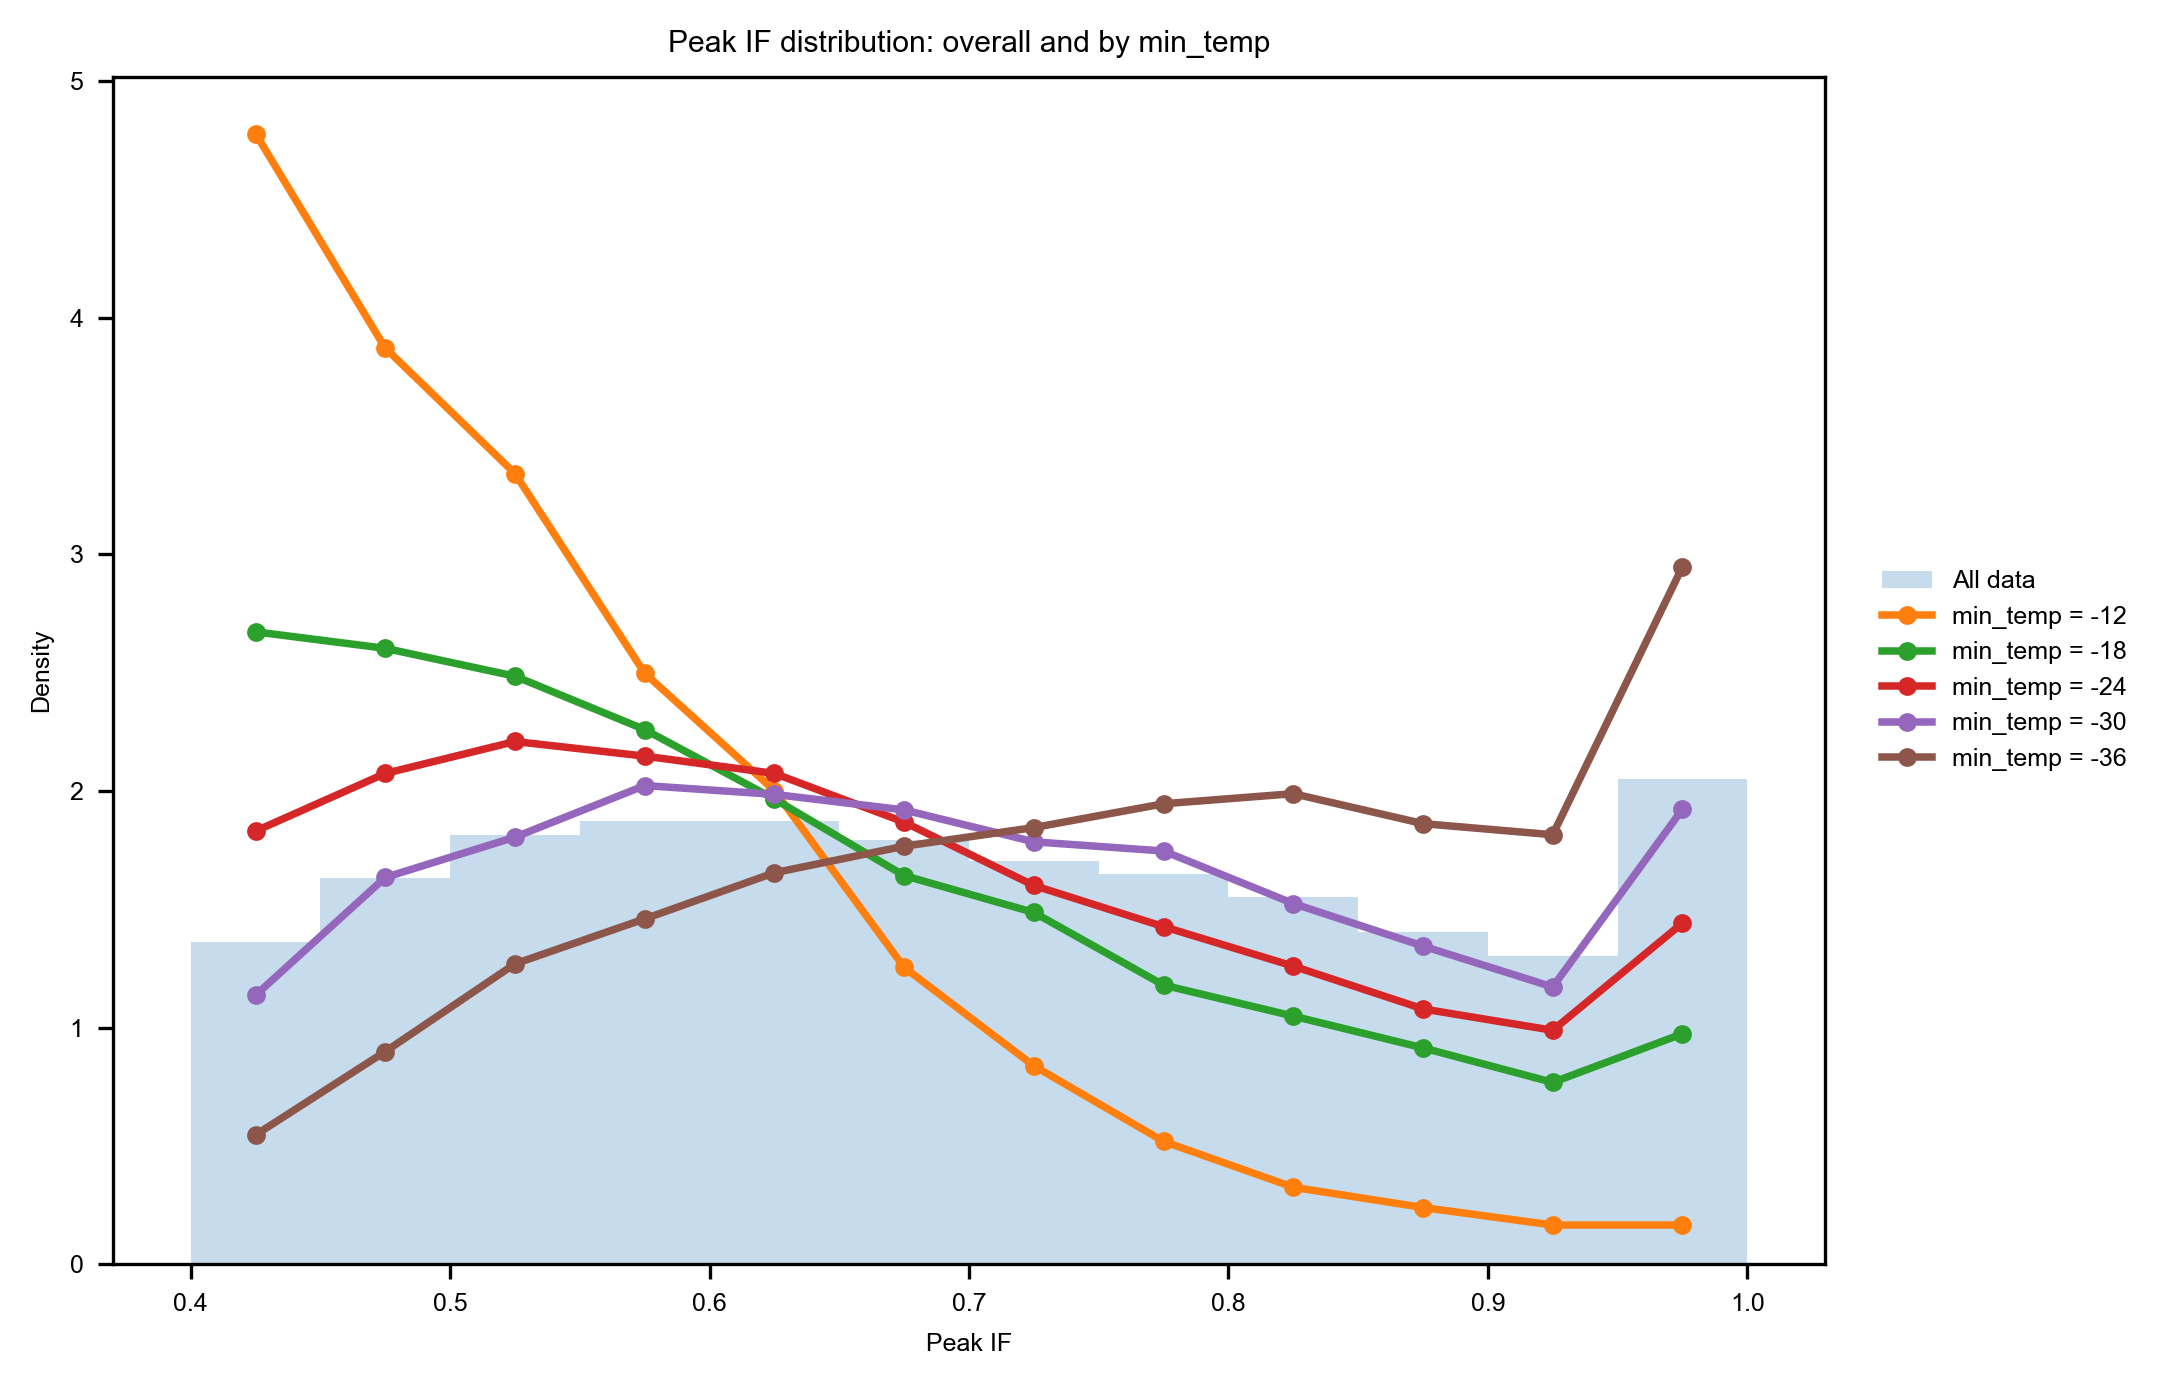

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== CONFIG (edit these) ============================================
value_col    = "Peak IF"
group_col    = "min_temp"
use_density  = False           # density=True => shapes comparable across group sizes
min_group_n  = 2              # skip tiny groups
top_k_groups = None           # e.g., 8 to keep only the largest K groups; or None for all

# You control bins here:
# - integer (e.g., 30)
# - rule string ('auto', 'fd', 'sturges', ...)
# - explicit edges array (e.g., np.linspace(0, 1, 31))
bins = 12
# ====================================================================

# --- data hygiene ---
df = glac_df[[value_col, group_col]].dropna()

# optionally keep only top-K most frequent groups
if top_k_groups is not None:
    keep = set(df[group_col].value_counts().head(top_k_groups).index)
    df = df[df[group_col].isin(keep)]

x_all = df[value_col].to_numpy()

# --- finalize common bin edges from your chosen `bins` ---
# Using np.histogram once to fix the edges for ALL plots
_, bin_edges = np.histogram(x_all, bins=bins, density=use_density)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# --- figure ---
plt.figure(figsize=(7.2, 4.6), dpi=300)

# 1) overall as a light filled histogram (bars)
plt.hist(
    x_all,
    bins=bin_edges,
    density=use_density,
    alpha=0.25,
    edgecolor="none",
    label="All data"
)

# 2) each subgroup as a line plot with circle markers at the bin centers
for g, sub in df.groupby(group_col, sort=False):
    x = sub[value_col].to_numpy()
    if x.size < min_group_n:
        continue
    y, _ = np.histogram(x, bins=bin_edges, density=use_density)
    plt.plot(
        bin_centers,
        y,
        marker="o",
        linewidth=1.8,
        markersize=3.5,
        label=f"{group_col} = {g}"
    )

plt.xlabel(value_col)
plt.ylabel("Density" if use_density else "Count")
plt.title(f"{value_col} distribution: overall and by {group_col}")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
# plt.savefig("peak_if_by_min_temp.svg", bbox_inches="tight")  # vector export for publication
plt.show()


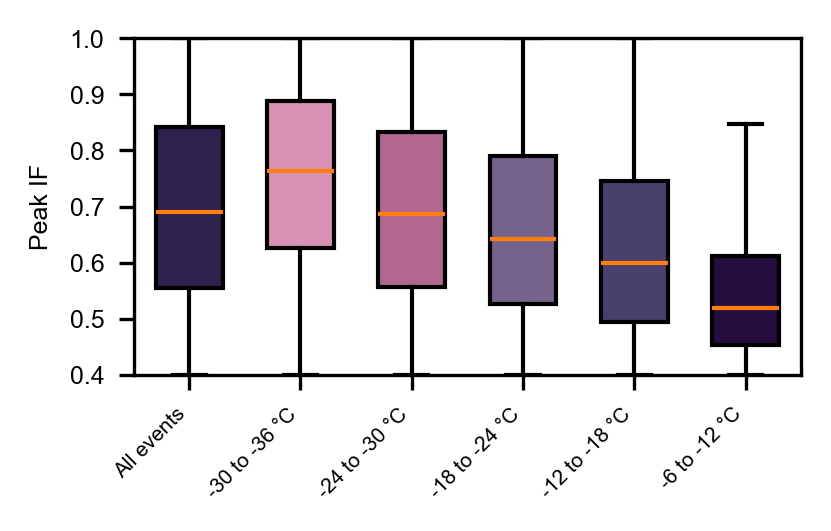

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(5.501/2, 3.504/2), dpi=300)
# Prepare data
all_data = glac_df["Peak IF"].dropna().values
min_temp_list = sorted(glac_df["min_temp"].unique())
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]

# Collect data arrays and labels
data_list = [all_data] + [
    glac_df[glac_df["min_temp"] == t]["Peak IF"].dropna().values
    for t in min_temp_list
]
labels = ["All events"] + [f"{int(t+6)} to {int(t)} °C" for t in min_temp_list]
colors = [classifiacation_palette[0]] + list(var_temp_cm)

# Create boxplots
# fig, ax = plt.subplots(figsize=(8, 6))
bplots = ax.boxplot(
    data_list,
    vert=True,
    patch_artist=True,
    labels=labels,
    widths=0.6,
    showfliers=False
)

# Apply colors
for box, color in zip(bplots['boxes'], colors):
    box.set_facecolor(color)
    box.set_edgecolor('black')
    box.set_linewidth(1)

# Styling
ax.set_ylabel("Peak IF")
# ax.set_title("Distribution of Peak IF by Temperature Bin")
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45, ha='right',fontsize=5)
plt.tight_layout()
plt.show()


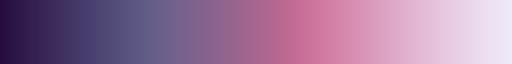

In [23]:
default_colormap

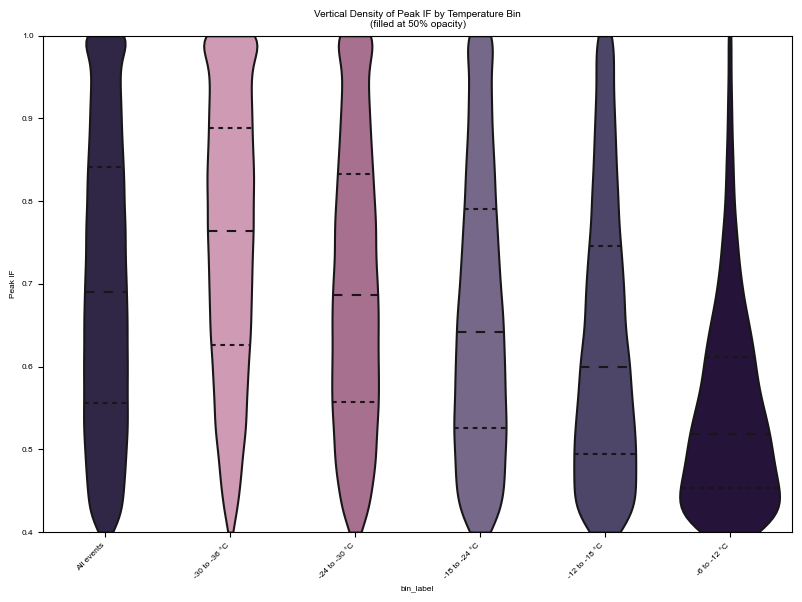

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare data
glac_plot = glac_df[["Peak IF", "min_temp"]].dropna().copy()
min_temp_list = sorted(glac_plot["min_temp"].unique())

all_label   = "All events"
bin_labels  = [f"{int(t+6)} to {int(t)} °C" for t in min_temp_list]

glac_plot["bin_label"] = glac_plot["min_temp"].map(
    {t: lab for t, lab in zip(min_temp_list, bin_labels)}
)
all_df = glac_plot.assign(bin_label=all_label)
glac_plot = pd.concat([all_df, glac_plot], ignore_index=True)

# 2. Build palette & order
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]
palette = [classifiacation_palette[0]] + list(var_temp_cm)
order   = [all_label] + bin_labels

# 3. Plot with semi-transparent fill
plt.figure(figsize=(8, 6))
sns.violinplot(
    x="bin_label",
    y="Peak IF",
    data=glac_plot,
    order=order,
    palette=palette,
    cut=0,
    inner="quartile",
    violin_kws={"alpha": 0.8}   # <-- set transparency here
)
plt.ylim(0.4, 1.0)
plt.ylabel("Peak IF")
plt.xticks(rotation=45, ha="right")
plt.title("Vertical Density of Peak IF by Temperature Bin\n(filled at 50% opacity)")
plt.tight_layout()
plt.show()


In [16]:
glac_plot['bin_label']

0            All events
1            All events
2            All events
3            All events
4            All events
              ...      
190783    -30 to -36 °C
190784    -30 to -36 °C
190785    -30 to -36 °C
190786    -30 to -36 °C
190787    -30 to -36 °C
Name: bin_label, Length: 190788, dtype: object

/tmp/ipykernel_7899/3888567385.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data

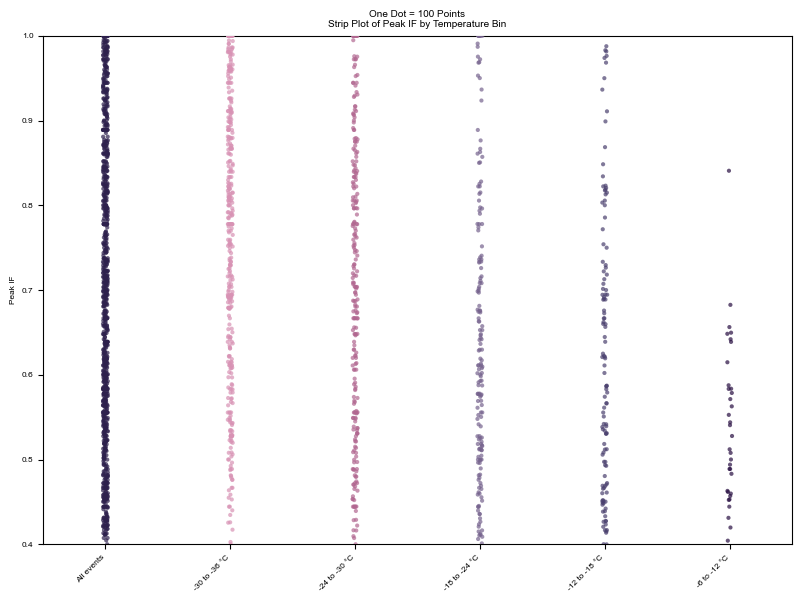

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare the full Glacier DataFrame
glac_plot = glac_df[["Peak IF", "min_temp"]].dropna().copy()
min_temp_list = sorted(glac_plot["min_temp"].unique())

all_label  = "All events"
bin_labels = [f"{int(t+6)} to {int(t)} °C" for t in min_temp_list]
bin_labels_lim = [f"{int(t+5)} to {int(t+1)} °C" for t in min_temp_list]
label_map  = {t: lab for t, lab in zip(min_temp_list, bin_labels)}

glac_plot["bin_label"] = glac_plot["min_temp"].map(label_map)
# duplicate for the overall distribution
all_df = glac_plot.assign(bin_label=all_label)
glac_plot = pd.concat([all_df, glac_plot], ignore_index=True)

# 2. Build palette & order
var_temp_cm = default_colormap(np.linspace(0, 0.7, len(min_temp_list)))[::-1]
palette = [classifiacation_palette[0]] + list(var_temp_cm)
order   = [all_label] + bin_labels

# 3. Aggregate into “one dot per 100 points”
n_per_dot = 100
dots = []
rng = np.random.default_rng(seed=42)
for lab in order:
    yvals = glac_plot.loc[glac_plot["bin_label"] == lab, "Peak IF"].values
    n_dots = len(yvals) // n_per_dot
    if n_dots > 0:
        # sample n_dots y‐values without replacement
        picks = rng.choice(yvals, size=n_dots, replace=False)
        for y in picks:
            dots.append({"bin_label": lab, "Peak IF": y})

dots_df = pd.DataFrame(dots)

# 4. Plot the aggregated stripplot
plt.figure(figsize=(8, 6))
sns.stripplot(
    x="bin_label",
    y="Peak IF",
    data=dots_df,
    order=order,
    palette=palette,
    size=3,       # size of each “100-point” dot
    jitter=0.02,   # spread them horizontally
    alpha=0.7     # semi‐transparent
)
plt.ylim(0.4, 1.0)
plt.ylabel("Peak IF")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.title("One Dot = 100 Points\nStrip Plot of Peak IF by Temperature Bin")
plt.tight_layout()
plt.show()


In [18]:
# !pip install joypy

/wolke_scratch/dnikolo/flex_trkr_env/lib/python3.11/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


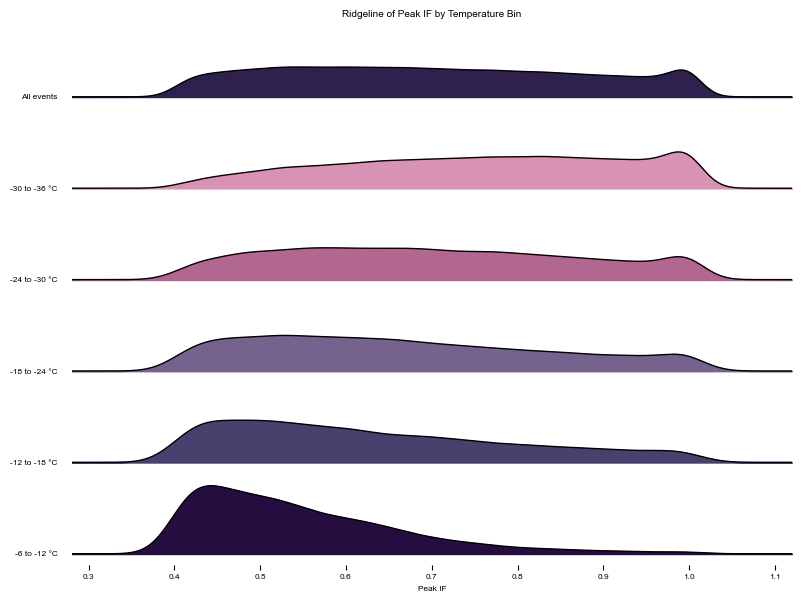

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import joypy

# 1. Make sure your bin labels are an ordered categorical,
#    so joyplot respects the order you want.
glac_plot['bin_label'] = pd.Categorical(
    glac_plot['bin_label'],
    categories=order,  # e.g. ["All events", "5 to -1 °C", ..., ...]
    ordered=True
)

# 2. Now call joyplot, using `color=` to pass your palette:
fig, axes = joypy.joyplot(
    data=glac_plot,
    by="bin_label",
    column="Peak IF",
    labels=order,     # group labels in the same order
    color=palette,    # one color per group
    overlap=1,        # how much they overlap
    linewidth=1,      # line width of each density
    figsize=(8, 6)
)

# 3. Tidy up the axes
plt.xlabel("Peak IF")
plt.title("Ridgeline of Peak IF by Temperature Bin")
plt.tight_layout()
plt.show()


# Draft versions

### Overall + Season Layout 

<bound method Figure.get_size_inches of <Figure size 350.4x300 with 3 Axes>>


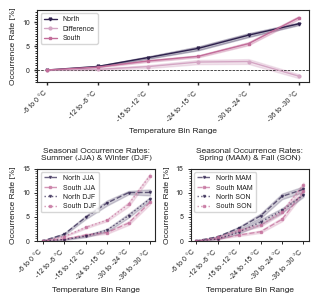

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or_glac_possible and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3))
gs = gridspec.GridSpec(2, 2, hspace=1.2, wspace=0.3)#height_ratios=[1, 1]

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3
)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title(f"Occurrence Rate of Glaciation by Temperature Bin\n"
#     r"in Non-Glaciated Clouds ($\mathregular{{IF_{{min}}}}<0.6$) "
#     f"for the period {min(years)} to {max(years)}",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)


ax1.set_yticks(large_minor_ticks,minor=True)
# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1, alpha=0.7,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1, alpha=0.7,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Seasonal Occurrence Rates:\nSummer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[1, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7, linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7, linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Seasonal Occurrence Rates:\nSpring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)


plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates_glac_possible.pdf",dpi=300)#, bbox_inches = "tight")
plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_right.pdf",dpi=300)#, bbox_inches = "tight")
print(fig.get_size_inches)
# plt.close()

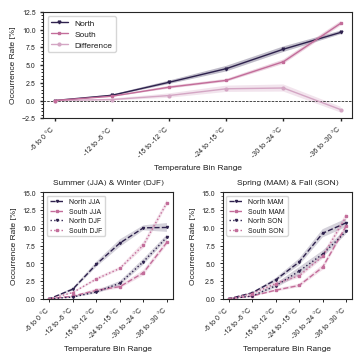

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.5), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)

ax1.set_xticks(x)
ax1.set_yticks(large_major_ticks)
ax1.set_yticks(large_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)
temp_handles, temp_labels = ax1.get_legend_handles_labels()
order = [0,2,1]
ax1.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2,edgecolor='none'
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2,edgecolor='none'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Summer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[1, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2,edgecolor='none'
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2,edgecolor='none'
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Spring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Multiyear_analysis/Occurance_rates.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

In [90]:
plt.close()

## Old Figure Versions

In [41]:
# assume your DataFrame is called df

# 1-st.norm.cdf(diff_df.groupby('min_temp')['diff'].mean() / diff_df.groupby('min_temp')['diff'].std())


/tmp/ipykernel_44134/2320470851.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '/wolke_scratch/dnikolo/Glaciation_time_estimator//Result_graphs/Publication_figures/Multiyear_analysis/Seasonal_occ_rates_non_glac.png'

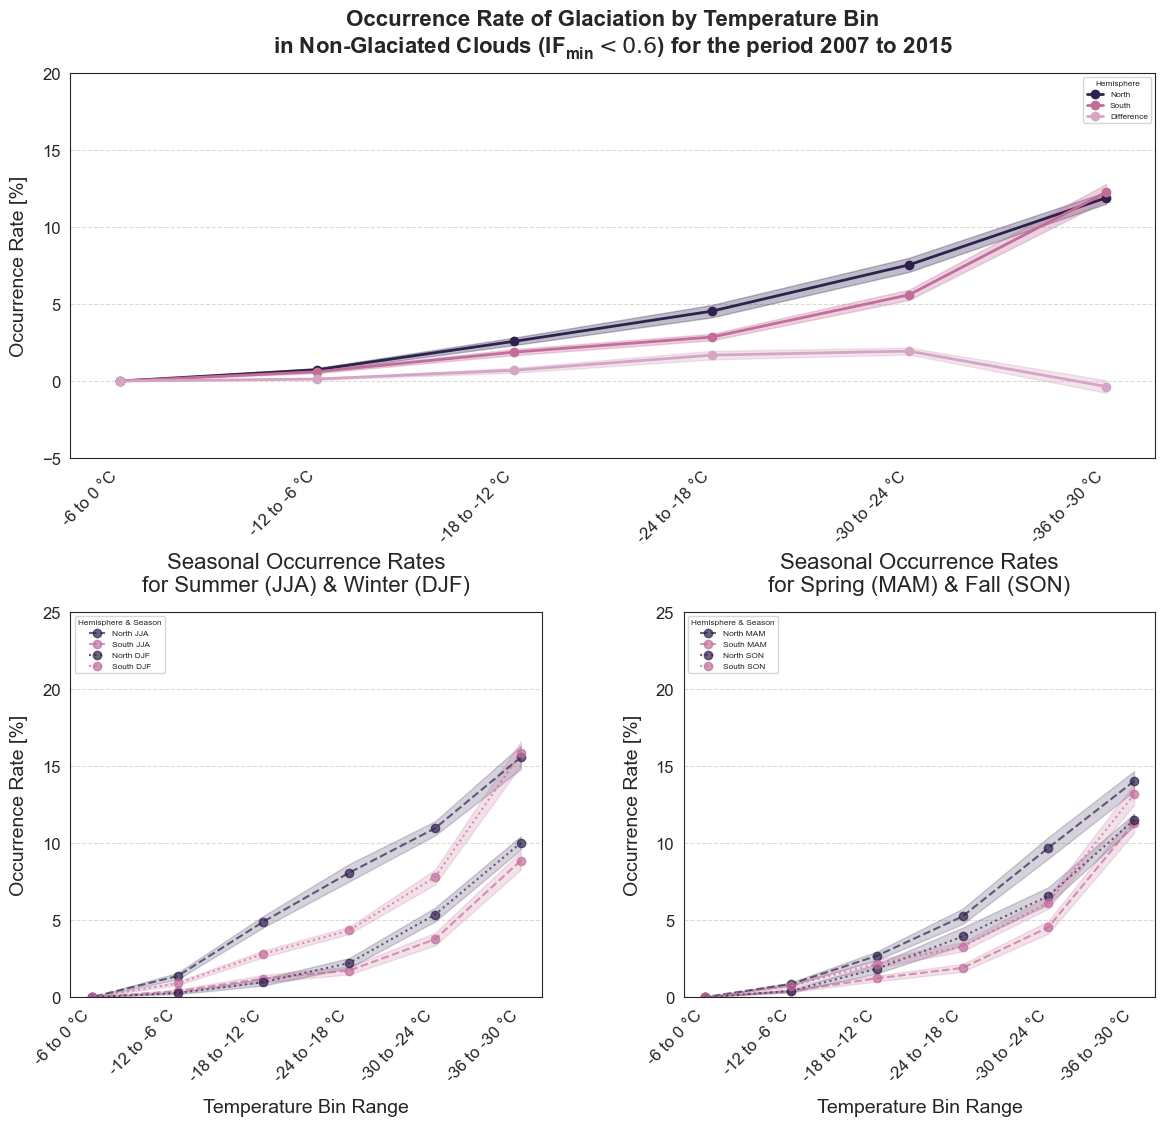

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or_glac_possible.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
# print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or_glac_possible
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or_glac_possible
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    r"in Non-Glaciated Clouds ($\mathregular{{IF_{{min}}}}<0.6$) "
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Publication_figures/Multiyear_analysis/Seasonal_occ_rates_non_glac.png", dpi=300)
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Publication_figures/Multiyear_analysis/Seasonal_occ_rates.png", dpi=300)
# plt.show()


Hemisphere         North      South
year min_temp                      
2007 -36        9.902444  10.785365
     -30        7.220691   5.427187
     -24        4.449587   2.823052
     -18        2.484720   1.813936
     -12        0.743626   0.580076
     -6         0.000000   0.000000
2008 -36        9.528375  10.810230
     -30        7.402934   5.357355
     -24        4.596888   2.766976
     -18        2.529138   1.799918
     -12        0.679957   0.596806
     -6         0.000000   0.000000
2009 -36        9.456826  10.541389
     -30        6.938630   5.095891
     -24        4.315120   2.669252
     -18        2.462080   1.738531
     -12        0.717297   0.564812
     -6         0.000000   0.000000
2010 -36        9.611457  11.268241
     -30        7.259360   5.735749
     -24        4.600676   2.970935
     -18        2.731036   1.936465
     -12        0.771413   0.613566
     -6         0.000000   0.000000
2011 -36        9.579088  11.235743
     -30        7.834016   6

/tmp/ipykernel_21122/991684146.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


## Figure testing

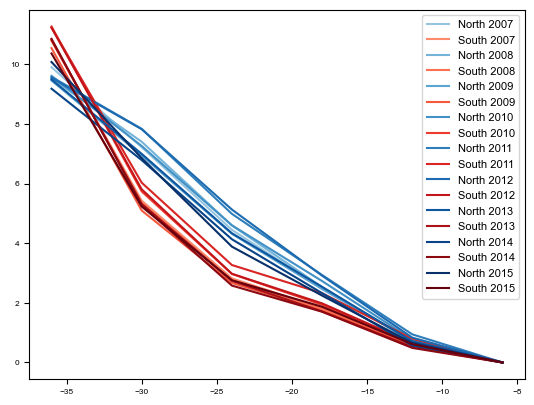

In [8]:
i=0
groups = pole_temp_or.groupby(["year","Hemisphere"])
n_groups = round(len(groups)/2)
# Generate two palettes from the Reds and Blues colormaps:
temperature_palette_north = plt.cm.Blues(np.linspace(0.4, 1, n_groups))
temperature_palette_south =  plt.cm.Reds(np.linspace(0.4, 1, n_groups))
for list in groups:
    Hemisphere= list[0][1]
    # print(Hemisphere)
    if Hemisphere == "North":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_north[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    if Hemisphere == "South":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_south[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    i+=1
plt.legend(loc='upper right', fontsize=8)
    

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# First, determine how many distinct (year, Hemisphere) groups you have:
groups = pole_temp_or.groupby(["year", "Hemisphere"])
n_groups = len(groups)

# # Generate two palettes from the Reds and Blues colormaps:
# temperature_palette_north = plt.cm.Reds(np.linspace(0.4, 1, n_groups))
# temperature_palette_south = plt.cm.Blues(np.linspace(0.4, 1, n_groups))

# # Now plot, pulling colors from those palettes in order:
# i = 0
# for (year, hemi), df_grp in groups:
#     if hemi == "North":
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_north[i],
#                  label=f"{hemi} {year}")
#     elif hemi == "South":          # fixed typo from "Sounth" → "South"
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_south[i],
#                  label=f"{hemi} {year}")
#     i += 1

# plt.xlabel("Minimum Temperature")
# plt.ylabel("Occurrence Rate")
# plt.legend(ncol=2, fontsize="small")
# plt.show()


In [10]:
or_list = -temp_or[temp_or['min_temp']==-24].values[0,1:]
or_list

array([-3.53718304, -3.64714438, -3.45052857, -3.72833853, -4.06273601,
       -3.98564364, -3.44686595, -3.2910717 , -3.27911727])

In [11]:
import pymannkendall as pkm

In [12]:
pkm.pre_whitening_modification_test(or_list, alpha=0.05)

Modified_Mann_Kendall_Test_PreWhitening_Approach(trend='no trend', h=False, p=0.38647623077123283, z=0.8660254037844386, Tau=0.2857142857142857, s=8.0, var_s=65.33333333333333, slope=0.033708491310959585, intercept=-3.672017003811918)

In [13]:
temp_or[pole_temp_or["Hemisphere"]=="North"]

/tmp/ipykernel_21122/71120718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_or[pole_temp_or["Hemisphere"]=="North"]


,min_temp,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,-36,10.483330,10.342348,10.121308,10.648339,10.623724,10.609363,10.357735,10.280185,10.256327
2,-24,3.537183,3.647144,3.450529,3.728339,4.062736,3.985644,3.446866,3.291072,3.279117
4,-12,0.671137,0.645124,0.653977,0.704925,0.880806,0.756470,0.627393,0.534463,0.638207


The glaciation occurance rate at each temperature range in the two hemispheres

In [14]:
# import matplotlib
# matplotlib.colormaps.register(cmap =cmcrameri.cm.managua,name = "managua")

In [15]:
# # Option 1: using .apply with a lambda (element-wise f-string)
# df_mean["Temperature range (°C)"] = df_mean.apply(
#     lambda row: f"{row['min_temp']} to {row['min_temp'] + 6} °C", axis=1
# )
# sns.lineplot(data = df_mean,x="Temperature range (°C)",y="mean", hue="Hemisphere",palette="managua")

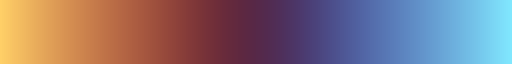

In [16]:
cmcrameri.cm.managua

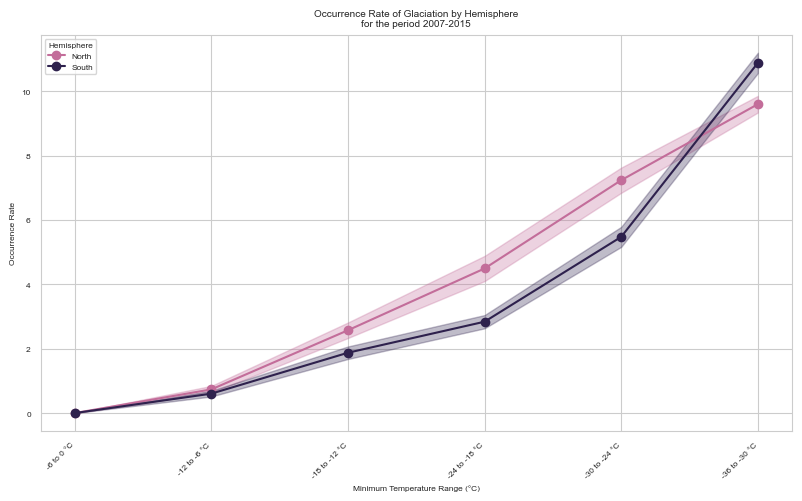

In [17]:
result_std = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2])#,cmap=cm.managua)
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


The glaciation occurance rate at each temperature range in the two hemispheres

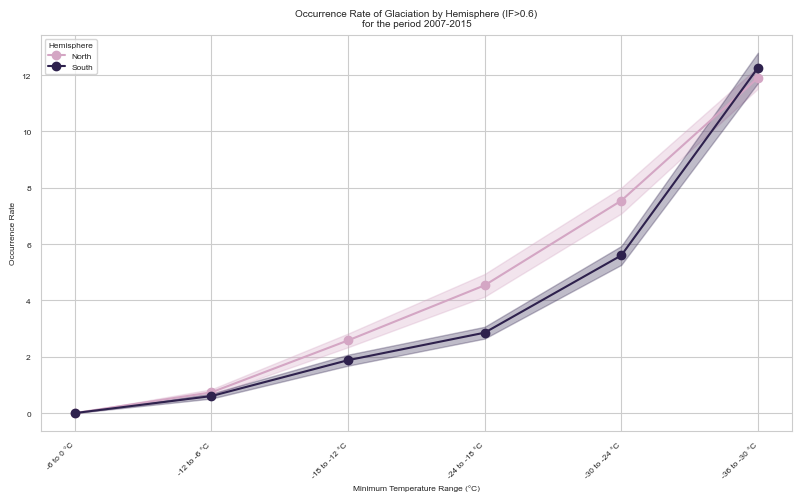

In [18]:
result_std = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2*2])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2*2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere (IF>0.6)\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


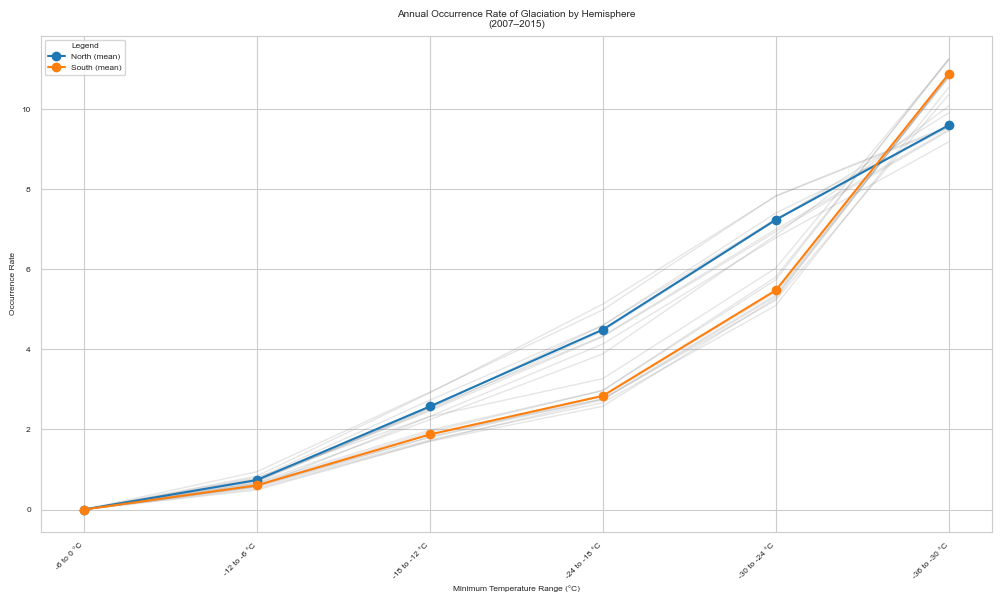

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming pole_temp_or is already defined in the environment

# Compute annual means by year, temperature bin, and hemisphere
annual = (
    pole_temp_or
    .groupby(['year', 'min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'annual_rate'})
)
annual['midpoint'] = annual['min_temp'] + 3

# Compute aggregated mean across all years for reference
agg_mean = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'mean_rate'})
)
agg_mean['midpoint'] = agg_mean['min_temp'] + 3

# Prepare x-axis ticks and labels
order = (
    annual[['midpoint', 'min_temp']]
    .drop_duplicates()
    .sort_values('midpoint')
)
midpoints = order['midpoint'].tolist()
labels = [f"{t} to {t+6} °C" for t in order['min_temp']]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each year's curve in transparent gray
for hemi in annual['Hemisphere'].unique():
    hemi_data = annual[annual['Hemisphere'] == hemi]
    for yr in sorted(hemi_data['year'].unique()):
        year_data = hemi_data[hemi_data['year'] == yr].sort_values('midpoint')
        ax.plot(
            year_data['midpoint'],
            year_data['annual_rate'],
            color='gray',
            alpha=0.2,
            linewidth=1
        )

# Overlay aggregated mean curves
for hemi in agg_mean['Hemisphere'].unique():
    mean_data = agg_mean[agg_mean['Hemisphere'] == hemi].sort_values('midpoint')
    ax.plot(
        mean_data['midpoint'],
        mean_data['mean_rate'],
        marker='o',
        label=f"{hemi} (mean)"
    )

# Configure axes
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.invert_xaxis()  # Coldest on the right
ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
years = sorted(pole_temp_or['year'].unique())
ax.set_title(f'Annual Occurrence Rate of Glaciation by Hemisphere\n({min(years)}–{max(years)})')
ax.legend(title='Legend')

plt.tight_layout()
plt.show()


In [20]:
pole_temp_season_or_glac_possible

,Unnamed: 0,Hemisphere,Season,min_temp,Occurance rate,year
0,0,North,DJF,-36,10.118556,2007
1,1,North,JJA,-36,15.446847,2007
2,2,North,MAM,-36,14.495766,2007
3,3,North,SON,-36,11.664822,2007
4,4,South,DJF,-36,16.011945,2007
...,...,...,...,...,...,...
427,427,North,SON,-6,0.000000,2015
428,428,South,DJF,-6,0.000000,2015
429,429,South,JJA,-6,0.000000,2015
430,430,South,MAM,-6,0.000000,2015


## Color palette testing

In [44]:
cmcrameri.cm.show_cmaps()

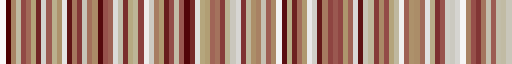

In [45]:
cmcrameri.cm.bilbaoS

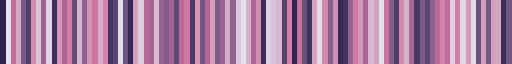

In [46]:
cmcrameri.cm.actonS

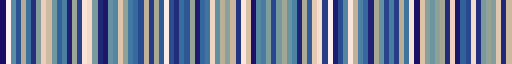

In [47]:
cmcrameri.cm.lapazS

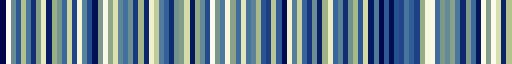

In [48]:
cmcrameri.cm.davosS

In [49]:
# classifiacation_palette = cmcrameri.cm.batlowS.colors[[3,4,2],:]
# classifiacation_palette = cmcrameri.cm.batlowWS.colors[1:4]
# classifiacation_palette = cmcrameri.cm.lapazS.colors[[0,2,3],:]
# classifiacation_palette = cmcrameri.cm.devonS.colors[[0,3,2],:]
# classifiacation_palette = cmcrameri.cm.davosS.colors[[0,3,2],:]
# classifiacation_palette = cmcrameri.cm.actonS.colors[[0,2,3],:]
# classifiacation_palette = cmcrameri.cm.bilbaoS.colors[[1,3,2],:]
classifiacation_palette

array([[0.180627, 0.129916, 0.300244],
       [0.763197, 0.428302, 0.605491],
       [0.829539, 0.652496, 0.769411]])

In [14]:
counts, bin_edges = np.histogram(
    data_2010,
    bins=100,
    range=(0.4, 1.0),
    density=False
)
# cumulative counts, normalized
cum_counts = np.cumsum(counts)
cdf = cum_counts / cum_counts[-1]

# plot at the right edges (or centers)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.step(bin_centers, cdf, where="mid")
plt.xlabel("Peak IF")
plt.ylabel("CDF (binned)")
plt.ylim(0, 1.05)
plt.xlim(0.4, 1.0)
plt.show()

TypeError: '>=' not supported between instances of 'ChunkLoader' and 'float'

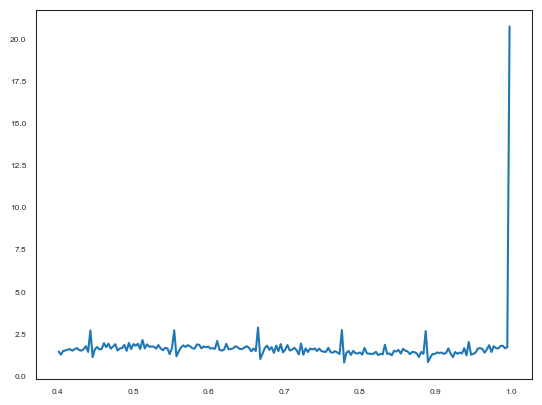

In [ ]:
pdf, bin_edges = np.histogram(
    glac_df[glac_df["avg_size[km]"]>10000]["Peak IF"].dropna(),
    bins=200,
    range=(0.4, 1.0),
    density=True
)

# if you want the x-coordinates (bin centers) for plotting:
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.plot(bin_centers, pdf)

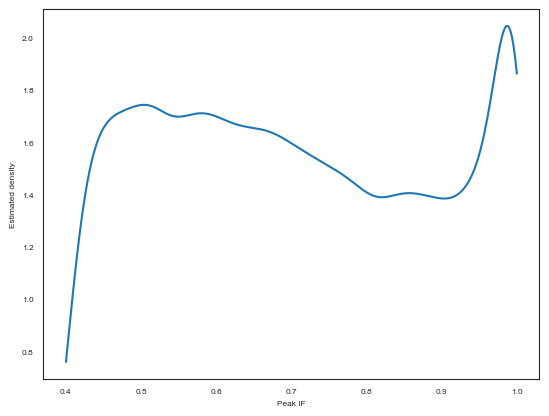

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np

data = glac_df[glac_df["avg_size[km]"]>10000]["Peak IF"].dropna().values
kde = gaussian_kde(data,)

# evaluate on a grid
x = np.linspace(0.4, 1.0, 500)
pdf_smooth = kde(x)
import matplotlib.pyplot as plt
plt.plot(x, pdf_smooth)
plt.xlabel("Peak IF")
plt.ylabel("Estimated density")
plt.show()